# Spider ET Boostfactor Determination

This notebook computes the uncorrected boostfactor from the transversely integrated ET data in `data/ET_results.npz`. It runs the same 1D fit chain for the reduced and full ET datasets in parallel and uses the root-level `MADBead` library.

In [13]:
using Statistics
using LinearAlgebra
using LsqFit
using LaTeXStrings
using Plots
using Plots.Measures
using DataFrames
using Distributions
using Measurements
using NPZ
using JLD2

const SPIDER_REPO = begin
    cwd = pwd()
    if basename(cwd) == "spider-bead-pull" && isfile(joinpath(cwd, "data", "ET_results.npz"))
        cwd
    elseif isfile(joinpath(cwd, "spider-bead-pull", "data", "ET_results.npz"))
        joinpath(cwd, "spider-bead-pull")
    else
        error("Run this notebook from the workspace root or from the spider-bead-pull directory.")
    end
end

const MADMAX_ROOT = normpath(joinpath(SPIDER_REPO, ".."))
include(joinpath(MADMAX_ROOT, "MADBead", "MADBead.jl"));

const DATA_FILE = joinpath(SPIDER_REPO, "data", "ET_results.npz")
const RESULTS_FILE = joinpath(SPIDER_REPO, "data", "5_result_bf_determination_spider_ET.jld2")


"/data/dust/user/salamana/madmax/spider-bead-pull/data/5_result_bf_determination_spider_ET.jld2"

## Load ET Data

The z positions in `ET_results.npz` are relative distances left of the mirror and map to $z_m - z$ as absolute values.

In [14]:
const REQUIRED_NPZ_KEYS = ["ETs_reduced", "ETs_full", "z_reduced", "z_full", "frequencies"]

function assert_finite_vector(name, values)
    @assert ndims(values) == 1 "$(name) must be a vector."
    @assert !isempty(values) "$(name) must not be empty."
    @assert all(isfinite.(values)) "$(name) contains non-finite values."
    return values
end

function orient_ET(name, ET_zf, ν, z_rel)
    @assert ndims(ET_zf) == 2 "$(name) must be a 2D array with shape (z, frequency)."
    @assert size(ET_zf, 1) == length(z_rel) "$(name) z dimension does not match its z array."
    @assert size(ET_zf, 2) == length(ν) "$(name) frequency dimension does not match frequencies."
    finite_mask = isfinite.(real.(ET_zf)) .& isfinite.(imag.(ET_zf))
    bad_count = count(.!finite_mask)
    if bad_count > 0
        @warn "$(name) contains $(bad_count) non-finite ET value(s); outlier cleanup will skip affected reduced frequencies."
    end
    return permutedims(ET_zf, (2, 1))
end

function make_ET_measurements(ET_fz; rel_err=0.05)
    @assert 0 <= rel_err < 1 "rel_err should be a fractional uncertainty."
    real_err = rel_err .* abs.(real.(ET_fz))
    imag_err = rel_err .* abs.(imag.(ET_fz))
    return (real.(ET_fz) .± real_err) .+ 1im .* (imag.(ET_fz) .± imag_err)
end

function build_dataset(label, ET_zf, z_rel, ν; z_mirror, rel_err)
    ET_fz = orient_ET("ETs_$(label)", ET_zf, ν, z_rel)
    z_abs = z_mirror .- z_rel
    @assert all(z_abs .< z_mirror) "$(label) z values must lie left of the mirror."

    order = sortperm(z_abs)
    ET_fz = ET_fz[:, order]
    z_rel = z_rel[order]
    z_abs = z_abs[order]

    return (
        label=label,
        z_rel=z_rel,
        z_abs=z_abs,
        ET=ET_fz,
        ET_meas=make_ET_measurements(ET_fz; rel_err=rel_err),
    )
end

function robust_median_mad(values)
    finite_values = collect(skipmissing(values[isfinite.(values)]))
    if isempty(finite_values)
        return 0.0, 0.0
    end
    med = median(finite_values)
    scale = 1.4826 * median(abs.(finite_values .- med))
    return med, scale
end

function hampel_component_flags(values; window=51, threshold=12.0)
    @assert isodd(window) "Hampel window must be odd."
    @assert window >= 3 "Hampel window must contain at least 3 points."
    x = Float64.(values)
    n = length(x)
    flags = falses(n)
    scores = zeros(Float64, n)

    global_med, global_scale = robust_median_mad(x)
    half_window = window ÷ 2

    for i in eachindex(x)
        if !isfinite(x[i])
            flags[i] = true
            scores[i] = Inf
            continue
        end

        lo = max(firstindex(x), i - half_window)
        hi = min(lastindex(x), i + half_window)
        neighbor_idx = vcat(collect(lo:i-1), collect(i+1:hi))
        neighbors = x[neighbor_idx]
        finite_neighbors = neighbors[isfinite.(neighbors)]

        local_med, local_scale = isempty(finite_neighbors) ? (global_med, global_scale) : robust_median_mad(finite_neighbors)
        scale = max(local_scale, global_scale, eps(Float64))
        scores[i] = abs(x[i] - local_med) / scale
        flags[i] = scores[i] > threshold
    end

    return flags, scores
end

function detect_reduced_ET_outliers(dataset, ν; window=51, threshold=12.0)
    @assert size(dataset.ET, 1) == length(ν) "Reduced ET frequency dimension must match ν."

    point_mask = falses(size(dataset.ET))
    real_score = zeros(Float64, size(dataset.ET))
    imag_score = zeros(Float64, size(dataset.ET))

    for z_idx in axes(dataset.ET, 2)
        real_flags, real_scores = hampel_component_flags(real.(dataset.ET[:, z_idx]); window=window, threshold=threshold)
        imag_flags, imag_scores = hampel_component_flags(imag.(dataset.ET[:, z_idx]); window=window, threshold=threshold)
        point_mask[:, z_idx] .= real_flags .| imag_flags
        real_score[:, z_idx] .= real_scores
        imag_score[:, z_idx] .= imag_scores
    end

    frequency_skip_mask = vec(any(point_mask, dims=2))
    keep_frequency_mask = .!frequency_skip_mask

    return (
        point_mask=point_mask,
        real_score=real_score,
        imag_score=imag_score,
        frequency_skip_mask=frequency_skip_mask,
        keep_frequency_mask=keep_frequency_mask,
        skipped_frequencies=ν[frequency_skip_mask],
        window=window,
        threshold=threshold,
    )
end

function apply_frequency_mask(values::AbstractVector, keep_frequency_mask)
    @assert length(values) == length(keep_frequency_mask) "Frequency mask length mismatch."
    return values[keep_frequency_mask]
end

function apply_frequency_mask(dataset::NamedTuple, keep_frequency_mask; label_suffix="clean")
    @assert size(dataset.ET, 1) == length(keep_frequency_mask) "Dataset frequency dimension does not match mask."
    return (
        label="$(dataset.label)_$(label_suffix)",
        z_rel=dataset.z_rel,
        z_abs=dataset.z_abs,
        ET=dataset.ET[keep_frequency_mask, :],
        ET_meas=dataset.ET_meas[keep_frequency_mask, :],
    )
end

function load_ET_results(data_file; z_mirror, rel_err=0.05)
    @assert isfile(data_file) "Missing ET data file: $(data_file)"
    data = npzread(data_file)
    for key in REQUIRED_NPZ_KEYS
        @assert haskey(data, key) "Missing key $(key) in $(data_file)."
    end

    ν = assert_finite_vector("frequencies", vec(Float64.(data["frequencies"])))
    @assert issorted(ν) "frequencies must be sorted in ascending order."

    z_reduced = assert_finite_vector("z_reduced", vec(Float64.(data["z_reduced"])))
    z_full = assert_finite_vector("z_full", vec(Float64.(data["z_full"])))
    ET_reduced = Array{ComplexF64}(data["ETs_reduced"])
    ET_full = Array{ComplexF64}(data["ETs_full"])

    reduced = build_dataset("reduced", ET_reduced, z_reduced, ν; z_mirror=z_mirror, rel_err=rel_err)
    full = build_dataset("full", ET_full, z_full, ν; z_mirror=z_mirror, rel_err=rel_err)

    return ν, reduced, full
end


load_ET_results (generic function with 1 method)

In [15]:
z_m_FM504_M = 2.298 ± 0.0
rel_err = 0.05
outlier_window = 51
outlier_threshold = 12.0

ν, reduced_data, full_data = load_ET_results(DATA_FILE; z_mirror=z_m_FM504_M.val, rel_err=rel_err)
reduced_outliers = detect_reduced_ET_outliers(reduced_data, ν; window=outlier_window, threshold=outlier_threshold)
ν_reduced_clean = apply_frequency_mask(ν, reduced_outliers.keep_frequency_mask)
ν_full = ν
reduced_data_clean = apply_frequency_mask(reduced_data, reduced_outliers.keep_frequency_mask)

n_skipped_reduced = count(reduced_outliers.frequency_skip_mask)
println("Loaded $(length(ν)) frequencies.")
println("Reduced ET: $(length(reduced_data.z_abs)) z points from $(first(reduced_data.z_abs)) m to $(last(reduced_data.z_abs)) m.")
println("Full ET:    $(length(full_data.z_abs)) z points from $(first(full_data.z_abs)) m to $(last(full_data.z_abs)) m.")
println("Reduced ET outlier cleanup: skipped $(n_skipped_reduced) / $(length(ν)) frequencies with window=$(outlier_window), threshold=$(outlier_threshold).")
if n_skipped_reduced > 0
    skipped_ghz = reduced_outliers.skipped_frequencies .* 1e-9
    println("Skipped reduced frequency range: $(first(skipped_ghz)) GHz to $(last(skipped_ghz)) GHz.")
end
println("Reduced clean fit grid: $(length(ν_reduced_clean)) frequencies.")
println("Full fit grid:          $(length(ν_full)) frequencies.")


┌ Warning: ETs_reduced contains 1 non-finite ET value(s); outlier cleanup will skip affected reduced frequencies.
└ @ Main In[14]:17


Loaded 1001 frequencies.
Reduced ET: 4 z points from 2.263 m to 2.2960000000000003 m.
Full ET:    17 z points from 2.2560000000000002 m to 2.2960000000000003 m.
Reduced ET outlier cleanup: skipped 42 / 1001 frequencies with window=51, threshold=12.0.
Skipped reduced frequency range: 18.306 GHz to 23.91 GHz.
Reduced clean fit grid: 959 frequencies.
Full fit grid:          1001 frequencies.


## Model Priors

In [16]:
ϵ_b = 9.23 ± 0.2
Δϵ = ϵ_b - 1
r_b = (2.93e-3 ± 15e-6) / 2
V_b = 4 / 3 * π * r_b^3
α_0 = 3 * Δϵ * V_b / (ϵ_b + 2)

P_in = 1
r_d = 0.15
A = π * r_d^2
σ_Al = (5.0 ± 1) * 1e7

ϵ_d = 9.3 ± 0.1
tanD_d = 1e-5 ± 1e-6
d_d = (1 ± 0.05) * 1e-3

δ_e_mie = [MADBead.calc_δ_e_mie(ϵ_b, r_b; f=f) for f in ν]
δ_c_mie = [MADBead.calc_δ_c_mie(ϵ_b, r_b; f=f) for f in ν]
δ_e_mie_full = δ_e_mie
δ_c_mie_full = δ_c_mie
δ_e_mie_reduced_clean = [MADBead.calc_δ_e_mie(ϵ_b, r_b; f=f) for f in ν_reduced_clean]
δ_c_mie_reduced_clean = [MADBead.calc_δ_c_mie(ϵ_b, r_b; f=f) for f in ν_reduced_clean]

n_disk = 3 ± 0
E0_0 = 1 ± 1
z_m_0 = z_m_FM504_M
σ_m_0 = σ_Al
d_v_i = [8.265 ± 0.1, 9.813 ± 0.1, 9.813 ± 0.1] * 1e-3

p0_all = Dict("E_0"=>E0_0, "z_m"=>z_m_0, "σ_m"=>σ_m_0, "n_disk"=>n_disk)
for i in 1:Int(n_disk.val)
    p0_all["d_v_$i"] = d_v_i[i]
    p0_all["d_d_$i"] = d_d
    p0_all["ϵ_d_$i"] = ϵ_d
    p0_all["tanD_d_$i"] = tanD_d
end
p0_all["r_b"] = r_b
p0_all["ϵ_b"] = ϵ_b

keys_optim = ["E_0", "d_v_1", "d_v_2", "d_v_3"]
keys_helper = ["n_disk"]
keys_fixed = [setdiff(keys(p0_all), keys_optim, keys_helper)...]
keys_all = [keys_optim..., keys_helper..., keys_fixed...]

N_mc = 100


100

## Shared Analysis Function

In [17]:
function final_parameter_table(ν, p_all_ν_mc, p0_all)
    p_final_ν = DataFrame("f"=>ν)
    for key in keys(p0_all)
        p_final_ν[!, key] = mean.(p_all_ν_mc[!, key]) .± std.(p_all_ν_mc[!, key])
    end
    return p_final_ν
end

function integrate_mc_fields(ν, p_all_ν_mc, p0_all, N_mc)
    int_dz_E_mc = zeros(ComplexF64, length(ν), N_mc)
    for f in 1:length(ν), i in 1:N_mc
        p_dict = Dict(key=>p_all_ν_mc[f, key][i] for key in keys(p0_all))
        int_dz_E_mc[f, i] = MADBead.int_dz_E_param(p_dict; f=ν[f])
    end
    return int_dz_E_mc
end

function boostfactor_from_int_dz(ν, int_dz_E_mc; P_in, A, J_0=1)
    ∫dV_E = mean(abs.(int_dz_E_mc), dims=2)[:] .± std(abs.(int_dz_E_mc), dims=2)[:]
    P_sig = J_0^2 / (16 * P_in) .* abs2.(∫dV_E)
    P_0 = MADBead.c_const * A * J_0^2 ./ (2 * MADBead.ϵ0 * (2π .* ν).^2)
    boostfactor = P_sig ./ P_0
    return ∫dV_E, boostfactor
end

function ET_dataframe(ν, dataset)
    df_ET = DataFrame("f"=>ν)
    df_ET[!, "ET"] = [dataset.ET_meas[f, :] for f in 1:length(ν)]
    df_ET[!, "z_abs"] = [dataset.z_abs for _ in 1:length(ν)]
    df_ET[!, "z_rel"] = [dataset.z_rel for _ in 1:length(ν)]
    return df_ET
end

function run_boostfactor_analysis(dataset, ν, p0_all, keys_optim, keys_fixed, keys_helper, N_mc; P_in, A)
    println("Running $(dataset.label) fit with $(length(dataset.z_abs)) z points and $(length(ν)) frequencies.")

    p_all_ν_mc = MADBead.fit_E_z_MC(ν, dataset.z_abs, dataset.ET_meas, p0_all, keys_optim, keys_fixed, keys_helper, N_mc)
    p_final_ν = final_parameter_table(ν, p_all_ν_mc, p0_all)
    int_dz_E_mc = integrate_mc_fields(ν, p_all_ν_mc, p0_all, N_mc)
    ∫dV_E, boostfactor = boostfactor_from_int_dz(ν, int_dz_E_mc; P_in=P_in, A=A)

    df_bf_analysis = DataFrame("f"=>ν, "bf"=>boostfactor, "int_dV_E"=>∫dV_E)
    df_bf_analysis = innerjoin(df_bf_analysis, p_final_ν, on="f")

    df_bf_mc_analysis = DataFrame("f"=>ν)
    df_bf_mc_analysis[!, "int_dV_E_mc"] = [int_dz_E_mc[f, :] for f in 1:length(ν)]
    df_bf_mc_analysis = innerjoin(df_bf_mc_analysis, p_all_ν_mc, on="f")

    return (
        label=dataset.label,
        p_all_ν_mc=p_all_ν_mc,
        p_final_ν=p_final_ν,
        int_dz_E_mc=int_dz_E_mc,
        ∫dV_E=∫dV_E,
        boostfactor=boostfactor,
        df_ET=ET_dataframe(ν, dataset),
        df_bf_analysis=df_bf_analysis,
        df_bf_mc_analysis=df_bf_mc_analysis,
    )
end


run_boostfactor_analysis (generic function with 1 method)

## ET Diagnostics

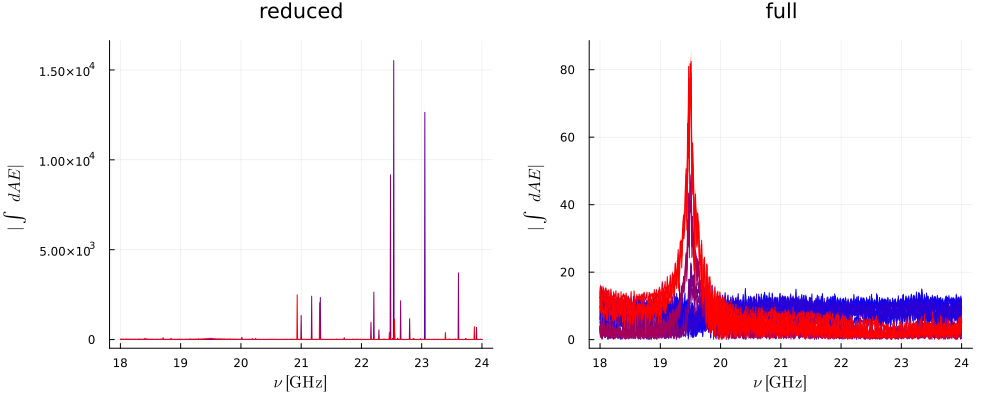

In [18]:
function plot_ET_magnitude(ν, dataset)
    color_fraction = length(dataset.z_abs) == 1 ? [0.5] : (dataset.z_abs .- first(dataset.z_abs)) ./ (last(dataset.z_abs) - first(dataset.z_abs))
    colors = cgrad([:blue, :red])[color_fraction]
    plt = plot(xlabel=L"ν \ \mathrm{[GHz]}", ylabel=L"|\int dA E|", title=dataset.label)
    for i in eachindex(dataset.z_abs)
        plot!(
            plt,
            ν .* 1e-9,
            getfield.(abs.(dataset.ET_meas[:, i]), :val),
            ribbon=getfield.(abs.(dataset.ET_meas[:, i]), :err),
            label="",
            c=colors[i],
            lw=1,
        )
    end
    return plt
end

function plot_reduced_outlier_components(ν, dataset, outliers)
    color_fraction = length(dataset.z_abs) == 1 ? [0.5] : (dataset.z_abs .- first(dataset.z_abs)) ./ (last(dataset.z_abs) - first(dataset.z_abs))
    colors = cgrad([:blue, :red])[color_fraction]
    p_re = plot(xlabel=L"ν \ \mathrm{[GHz]}", ylabel=L"\mathrm{Re}(\int dA E)", title="reduced Re(ET) outlier check")
    p_im = plot(xlabel=L"ν \ \mathrm{[GHz]}", ylabel=L"\mathrm{Im}(\int dA E)", title="reduced Im(ET) outlier check")

    for i in eachindex(dataset.z_abs)
        z_label = "z=$(round(dataset.z_rel[i] * 1e3, digits=1)) mm rel"
        plot!(p_re, ν .* 1e-9, real.(dataset.ET[:, i]), c=colors[i], lw=1, alpha=0.75, label=z_label)
        plot!(p_im, ν .* 1e-9, imag.(dataset.ET[:, i]), c=colors[i], lw=1, alpha=0.75, label=z_label)

        flagged = outliers.point_mask[:, i]
        if any(flagged)
            scatter!(p_re, ν[flagged] .* 1e-9, real.(dataset.ET[flagged, i]), c=:black, ms=3, label="")
            scatter!(p_im, ν[flagged] .* 1e-9, imag.(dataset.ET[flagged, i]), c=:black, ms=3, label="")
        end
    end

    return plot(p_re, p_im, layout=(2, 1), size=(1000, 650), margin=5mm)
end

plot(
    plot_ET_magnitude(ν, reduced_data),
    plot_ET_magnitude(ν, full_data),
    layout=(1, 2),
    size=(1000, 400),
    margin=5mm,
)


## Reduced ET Outlier Diagnostics

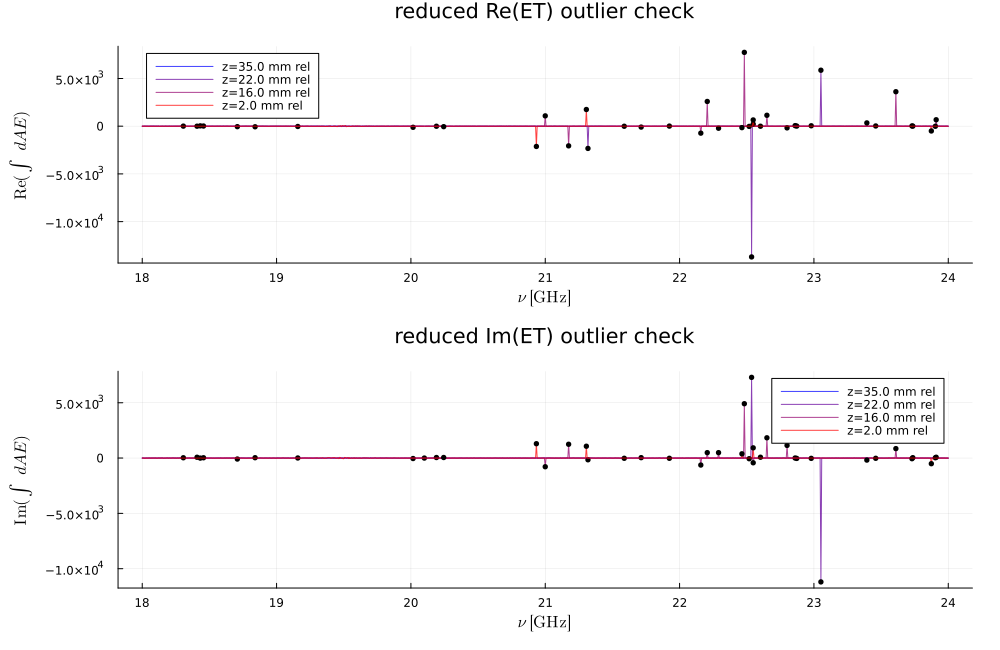

In [19]:
plot_reduced_outlier_components(ν, reduced_data, reduced_outliers)


## Run Fits

In [20]:
reduced_result = run_boostfactor_analysis(reduced_data_clean, ν_reduced_clean, p0_all, keys_optim, keys_fixed, keys_helper, N_mc; P_in=P_in, A=A);
full_result = run_boostfactor_analysis(full_data, ν_full, p0_all, keys_optim, keys_fixed, keys_helper, N_mc; P_in=P_in, A=A);

@assert isempty(intersect(reduced_result.df_bf_analysis.f, reduced_outliers.skipped_frequencies)) "Skipped reduced frequencies leaked into reduced fit output."
@assert length(full_result.df_bf_analysis.f) == length(ν_full) "Full fit should use the complete frequency grid."


Running reduced_clean fit with 4 z points and 959 frequencies.
Running full fit with 17 z points and 1001 frequencies.


## Representative Fit Diagnostics

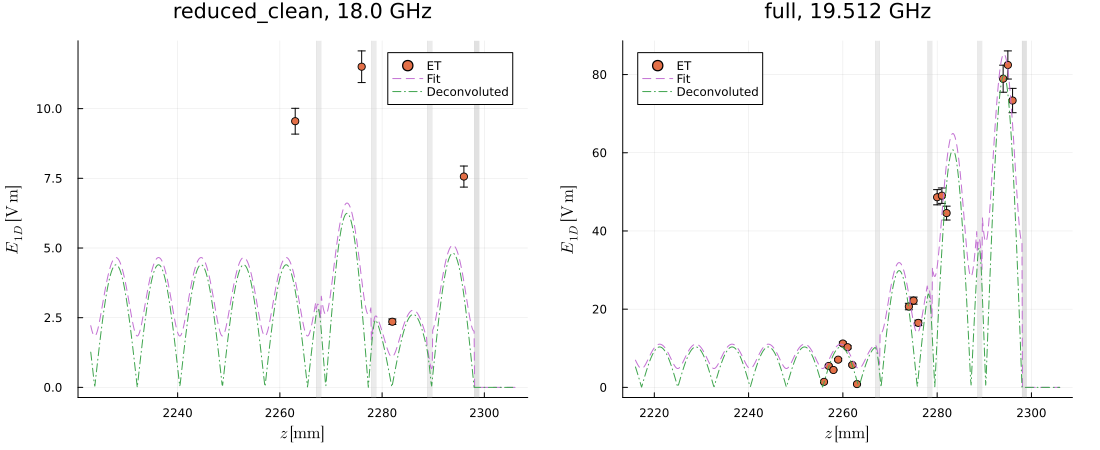

In [21]:
function plot_representative_fit(ν, dataset, result, p0_all, δ_e_mie, δ_c_mie; mc_idx=1)
    freq_idx = argmax(abs.(getfield.(result.p_final_ν[!, "E_0"], :val)))
    p_select = Dict(key=>result.p_all_ν_mc[freq_idx, key][mc_idx] for key in keys(p0_all))

    distance_fit, ignore, ignore = MADBead.fit_param_to_model(p_select)
    z_σ = sum(distance_fit) .+ [0, 1e-3]
    z_ϵ = [sum(distance_fit[2*i+1:end]) .+ [0, -1e-3] for i in 1:Int(p0_all["n_disk"].val)]
    z_pos_fit = (first(dataset.z_abs) - 0.04):1e-4:(last(dataset.z_abs) + 0.01)

    δ_mie_select = real.(δ_e_mie[freq_idx]).val + 1im * imag.(δ_e_mie[freq_idx]).val
    δc_mie_select = real.(δ_c_mie[freq_idx]).val + 1im * imag.(δ_c_mie[freq_idx]).val

    fit_plot = sqrt.(abs.(MADBead.E_field2_conv_1D_z_param(z_pos_fit, p_select; f=ν[freq_idx], δ=δ_mie_select, δc=δc_mie_select)))
    deconv_plot = abs.(MADBead.E_field_1D_z_param(z_pos_fit, p_select; f=ν[freq_idx]))

    plt = plot(title="$(dataset.label), $(round(ν[freq_idx] * 1e-9, digits=3)) GHz")
    vspan!(plt, z_σ .* 1e3, label="", c=:darkgrey, alpha=0.35)
    for region in z_ϵ
        vspan!(plt, region .* 1e3, label="", c=:lightgrey, alpha=0.45)
    end
    scatter!(plt, dataset.z_abs .* 1e3, abs.(dataset.ET_meas[freq_idx, :]), msw=1, c=2, label="ET")
    plot!(plt, z_pos_fit .* 1e3, fit_plot, c=4, ls=:dash, label="Fit")
    plot!(plt, z_pos_fit .* 1e3, deconv_plot, c=3, ls=:dashdot, label="Deconvoluted")
    plot!(plt, xlabel=L"z \: \mathrm{[mm]}", ylabel=L"E_{1D} \: \mathrm{[Vm]}")
    return plt
end

plot(
    plot_representative_fit(ν_reduced_clean, reduced_data_clean, reduced_result, p0_all, δ_e_mie_reduced_clean, δ_c_mie_reduced_clean),
    plot_representative_fit(ν_full, full_data, full_result, p0_all, δ_e_mie_full, δ_c_mie_full),
    layout=(1, 2),
    size=(1100, 450),
    margin=5mm,
)


## Fitted Parameters

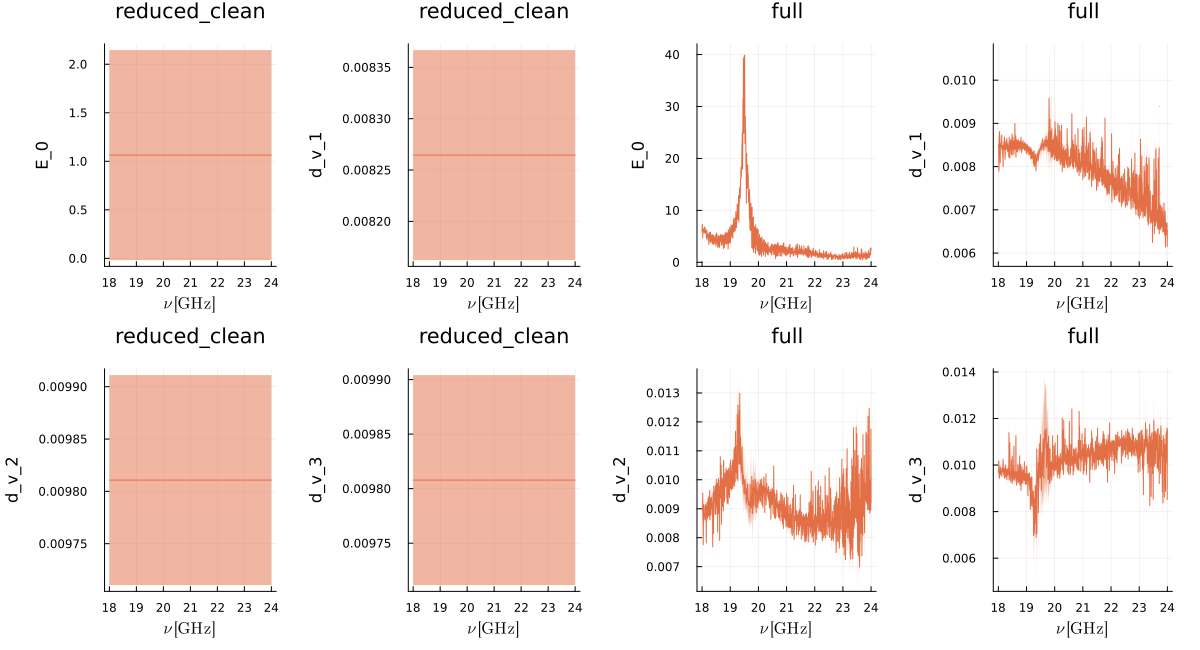

In [22]:
function plot_fit_parameters(ν, result, keys_optim)
    ncol = ceil(Int, sqrt(length(keys_optim)))
    nrow = ceil(Int, length(keys_optim) / ncol)
    plt = plot(layout=(nrow, ncol), size=(900, 650))
    for (sp, key) in enumerate(keys_optim)
        plot!(
            plt,
            sp=sp,
            ν .* 1e-9,
            getfield.(result.p_final_ν[!, key], :val),
            ribbon=getfield.(result.p_final_ν[!, key], :err),
            label="",
            c=2,
            xlabel=L"ν \: \mathrm{[GHz]}",
            ylabel=key,
            title=result.label,
        )
    end
    return plt
end

plot(
    plot_fit_parameters(ν_reduced_clean, reduced_result, keys_optim),
    plot_fit_parameters(ν_full, full_result, keys_optim),
    layout=(1, 2),
    size=(1200, 650),
    margin=5mm,
)


## Boostfactor

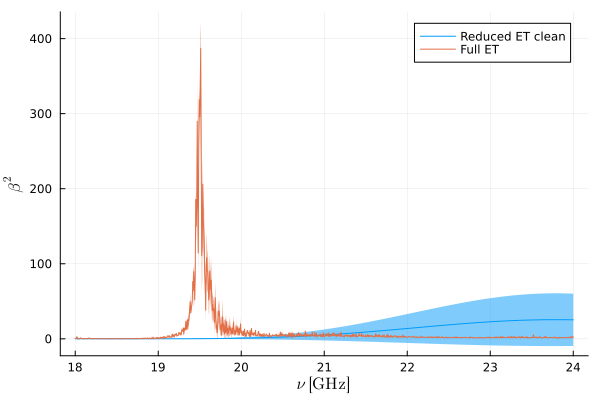

In [23]:
plot()
plot!(
    ν_reduced_clean .* 1e-9,
    getfield.(reduced_result.boostfactor, :val),
    ribbon=getfield.(reduced_result.boostfactor, :err),
    lw=1,
    label="Reduced ET clean",
)
plot!(
    ν_full .* 1e-9,
    getfield.(full_result.boostfactor, :val),
    ribbon=getfield.(full_result.boostfactor, :err),
    lw=1,
    label="Full ET",
)
plot!(xlabel=L"ν \  \mathrm{[GHz]}", ylabel=L"\beta^2")
plot!()


## Save Results

In [24]:
mkpath(dirname(RESULTS_FILE))

ν_reduced = ν_reduced_clean
outlier_point_mask_reduced_fz = reduced_outliers.point_mask
outlier_real_score_reduced_fz = reduced_outliers.real_score
outlier_imag_score_reduced_fz = reduced_outliers.imag_score
outlier_frequency_skip_mask_reduced = reduced_outliers.frequency_skip_mask
outlier_keep_frequency_mask_reduced = reduced_outliers.keep_frequency_mask
skipped_frequencies_reduced = reduced_outliers.skipped_frequencies
outlier_window_reduced = outlier_window
outlier_threshold_reduced = outlier_threshold

z_reduced_abs = reduced_data.z_abs
z_reduced_rel = reduced_data.z_rel
ET_reduced_raw = reduced_data.ET
ET_reduced_meas_raw = reduced_data.ET_meas
ET_reduced = reduced_data_clean.ET
ET_reduced_meas = reduced_data_clean.ET_meas
p_all_ν_mc_reduced = reduced_result.p_all_ν_mc
p_final_ν_reduced = reduced_result.p_final_ν
int_dz_E_mc_reduced = reduced_result.int_dz_E_mc
∫dV_E_reduced = reduced_result.∫dV_E
boostfactor_reduced = reduced_result.boostfactor
df_ET_reduced = reduced_result.df_ET
df_ET_reduced_raw = ET_dataframe(ν, reduced_data)
df_bf_analysis_reduced = reduced_result.df_bf_analysis
df_bf_mc_analysis_reduced = reduced_result.df_bf_mc_analysis

z_full_abs = full_data.z_abs
z_full_rel = full_data.z_rel
ET_full = full_data.ET
ET_full_meas = full_data.ET_meas
p_all_ν_mc_full = full_result.p_all_ν_mc
p_final_ν_full = full_result.p_final_ν
int_dz_E_mc_full = full_result.int_dz_E_mc
∫dV_E_full = full_result.∫dV_E
boostfactor_full = full_result.boostfactor
df_ET_full = full_result.df_ET
df_bf_analysis_full = full_result.df_bf_analysis
df_bf_mc_analysis_full = full_result.df_bf_mc_analysis

JLD2.jldsave(
    RESULTS_FILE;
    ν,
    ν_full,
    ν_reduced,
    ν_reduced_clean,
    z_m_FM504_M,
    rel_err,
    N_mc,
    p0_all,
    keys_optim,
    keys_helper,
    keys_fixed,
    outlier_point_mask_reduced_fz,
    outlier_real_score_reduced_fz,
    outlier_imag_score_reduced_fz,
    outlier_frequency_skip_mask_reduced,
    outlier_keep_frequency_mask_reduced,
    skipped_frequencies_reduced,
    outlier_window_reduced,
    outlier_threshold_reduced,
    z_reduced_abs,
    z_reduced_rel,
    ET_reduced_raw,
    ET_reduced_meas_raw,
    ET_reduced,
    ET_reduced_meas,
    p_all_ν_mc_reduced,
    p_final_ν_reduced,
    int_dz_E_mc_reduced,
    ∫dV_E_reduced,
    boostfactor_reduced,
    df_ET_reduced,
    df_ET_reduced_raw,
    df_bf_analysis_reduced,
    df_bf_mc_analysis_reduced,
    z_full_abs,
    z_full_rel,
    ET_full,
    ET_full_meas,
    p_all_ν_mc_full,
    p_final_ν_full,
    int_dz_E_mc_full,
    ∫dV_E_full,
    boostfactor_full,
    df_ET_full,
    df_bf_analysis_full,
    df_bf_mc_analysis_full,
)

println("Saved boostfactor results to $(RESULTS_FILE)")


Saved boostfactor results to /data/dust/user/salamana/madmax/spider-bead-pull/data/5_result_bf_determination_spider_ET.jld2
